In [1]:
import pandas as pd
import numpy as np
import deepchem as dc
from utils import to_canonical_smiles
df = pd.read_csv('..\..\ml\shareddata\All_column_charity.csv')
df['canonical_smiles'] = df['SMILES'].apply(to_canonical_smiles)
df

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\gzyla\Documents\projects\HPLC\HPLC_ML_Leaderboard\venv\lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-lig

,Unnamed: 0,index,SMILES,RT,Speed,i-PrOH_proportion,Literature,Column,canonical_smiles
0,0,0,O=C(OC)N(C)[C@@H](B1OC(C)(C)C(C)(C)O1)CC2=CC=C...,2.14,0.5,0.050000,10.1039/C9SC04534A,OJ3,COC(=O)N(C)[C@H](Cc1ccccc1)B1OC(C)(C)C(C)(C)O1
1,1,0,O=C(OC)N(C)[C@H](B1OC(C)(C)C(C)(C)O1)CC2=CC=CC=C2,1.81,0.5,0.050000,10.1039/C9SC04534A,OJ3,COC(=O)N(C)[C@@H](Cc1ccccc1)B1OC(C)(C)C(C)(C)O1
2,2,1,C=CCCCCCCC[C@@H](C[C@@]1(CCCC1=O)c2ccccc2)C=O,0.97,2.0,0.076923,10.1002/anie.202001100,AD3,C=CCCCCCCC[C@H](C=O)C[C@]1(c2ccccc2)CCCC1=O
3,3,2,C[C@H](C[S](=O)(=O)c1ccc(C)cc1)c2ccc(cc2)C(F)(F)F,2.13,0.5,0.300000,10.1039/C8QO01291A,IA,Cc1ccc(S(=O)(=O)C[C@@H](C)c2ccc(C(F)(F)F)cc2)cc1
4,4,2,C[C@@H](C[S](=O)(=O)c1ccc(C)cc1)c2ccc(cc2)C(F)...,2.30,0.5,0.300000,10.1039/C8QO01291A,IA,Cc1ccc(S(=O)(=O)C[C@H](C)c2ccc(C(F)(F)F)cc2)cc1
...,...,...,...,...,...,...,...,...,...
25862,25862,14144,COc1ccc2N(COCc3ccccc3)C(=O)[C@](CO)(\C=C\c4ccc...,119.10,0.8,0.050000,10.31635/ccschem.019.20190064,IC3,COc1ccc2c(c1)[C@](/C=C/c1ccccc1)(CO)C(=O)N2COC...
25863,25863,14144,COc1ccc2N(COCc3ccccc3)C(=O)[C@@](CO)(\C=C\c4cc...,98.90,0.8,0.050000,10.31635/ccschem.019.20190064,IC3,COc1ccc2c(c1)[C@@](/C=C/c1ccccc1)(CO)C(=O)N2CO...
25864,25864,14145,Fc1cccc2[C@@H](OC(=O)C(c3ccccc3)c4ccccc4)OC(=O...,75.30,0.8,0.100000,10.1002/anie.202012445,IC3,O=C1O[C@H](OC(=O)C(c2ccccc2)c2ccccc2)c2cccc(F)c21
25865,25865,14145,Fc1cccc2[C@H](OC(=O)C(c3ccccc3)c4ccccc4)OC(=O)c12,99.60,0.8,0.100000,10.1002/anie.202012445,IC3,O=C1O[C@@H](OC(=O)C(c2ccccc2)c2ccccc2)c2cccc(F...


In [4]:

# Ensure 'index' and 'RT' columns are of appropriate types
# It's good practice to strip whitespace before converting to numeric,
# in case there are hidden spaces from data ingestion.
df['index'] = df['index'].astype(str).str.strip().astype(int)
df['RT'] = pd.to_numeric(df['RT'])

paired_rows_data = []
for index_val, group in df.groupby('index'):
    # Check if there are exactly two entries for the 'index' to form a pair
    if len(group) == 2:
        # Calculate the absolute difference of 'RT' values
        rt_diff = abs(group['RT'].iloc[0] - group['RT'].iloc[1])
        # Get both rows of the pair
        row1_data = group.iloc[0].copy()
        row2_data = group.iloc[1].copy()
        

        # Add the calculated difference to both rows' data
        row1_data['RT_difference'] = rt_diff
        row2_data['RT_difference'] = rt_diff

        # Append both modified rows to the list
        paired_rows_data.append(row1_data)
        paired_rows_data.append(row2_data)


# Create a new DataFrame from the collected data

paired_df = pd.DataFrame(paired_rows_data)
# Sort by RT_difference from largest to smallest
paired_df = paired_df.sort_values(by=['RT_difference', 'index'], ascending=[False, True])
    
paired_df





,Unnamed: 0,index,SMILES,RT,Speed,i-PrOH_proportion,Literature,Column,canonical_smiles,RT_difference
16378,16378,8793,Clc1cccc(c1)[C@@H]2CC(=O)N=C(S2)c3ccccc3,27.00,0.6,0.02,10.1021/acs.orglett.9b03685,ADH,O=C1C[C@@H](c2cccc(Cl)c2)SC(c2ccccc2)=N1,194.50
16379,16379,8793,Clc1cccc(c1)[C@H]2CC(=O)N=C(S2)c3ccccc3,221.50,0.6,0.02,10.1021/acs.orglett.9b03685,ADH,O=C1C[C@H](c2cccc(Cl)c2)SC(c2ccccc2)=N1,194.50
9816,9816,5194,Cc1ccc(C[C@](C)(O)CC(N)c2ccccc2)cc1,19.31,0.8,0.30,10.1002/anie.201912408,OJH,Cc1ccc(C[C@](C)(O)CC(N)c2ccccc2)cc1,105.69
9817,9817,5194,Cc1ccc(C[C@@](C)(O)CC(N)c2ccccc2)cc1,125.00,0.8,0.30,10.1002/anie.201912408,OJH,Cc1ccc(C[C@@](C)(O)CC(N)c2ccccc2)cc1,105.69
6555,6555,3394,CC(CCCC#N)[C@@H](OC(=O)c1ccc(C)cc1)\C(C)=C\c2c...,70.57,0.5,0.05,10.1021/jacs.1c06535,IC,C/C(=C\c1ccccc1)[C@H](OC(=O)c1ccc(C)cc1)C(C)CC...,77.13
...,...,...,...,...,...,...,...,...,...,...
25727,25727,14067,O=C(Nc1ccc(cc1)[C@@H](n2c3ccccc3c(c4ccccc4)c2c...,9.90,1.0,0.10,10.1002/anie.201701947,IC,O=C(Nc1ccc([C@H](c2ccc3ccccc3c2)n2c(-c3ccccc3)...,0.10
21395,21395,11630,OCC[C@@H](CO)c1ccccc1,50.70,1.0,0.03,10.1039/C6SC04609F,AD3,OCC[C@@H](CO)c1ccccc1,0.08
21396,21396,11630,OCC[C@H](CO)c1ccccc1,50.78,1.0,0.03,10.1039/C6SC04609F,AD3,OCC[C@H](CO)c1ccccc1,0.08
11186,11186,5947,CC(C)(C)[S](=O)(=O)N1[C@H]2C=CCC[C@H]2C=C1c3cc...,14.57,0.8,0.20,10.1002/adsc.202000151,IE,CC(C)(C)S(=O)(=O)N1C(c2cccc(F)c2)=C[C@@H]2CCC=...,0.00


In [6]:
indices_to_keep = []
for pair_index, pair_group in paired_df.groupby('index'):
        speed_differs = pair_group['Speed'].nunique() > 1
        i_proh_differs = pair_group['i-PrOH_proportion'].nunique() > 1

        if speed_differs or i_proh_differs:
            indices_to_keep.append(pair_index)

    # Filter the original ranked_paired_data to include only these pairs
filtered_pairs = paired_df[paired_df['index'].isin(indices_to_keep)]

if not filtered_pairs.empty:
        print("--- Pairs where 'Speed' and/or 'i-PrOH_proportion' differ ---")
        print(filtered_pairs.to_string())
else:
        print("No pairs found where 'Speed' or 'i-PrOH_proportion' differ.")


No pairs found where 'Speed' or 'i-PrOH_proportion' differ.


Might need to batch similar compounds

C:\Users\gzyla\AppData\Local\Temp\ipykernel_12060\2583883443.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


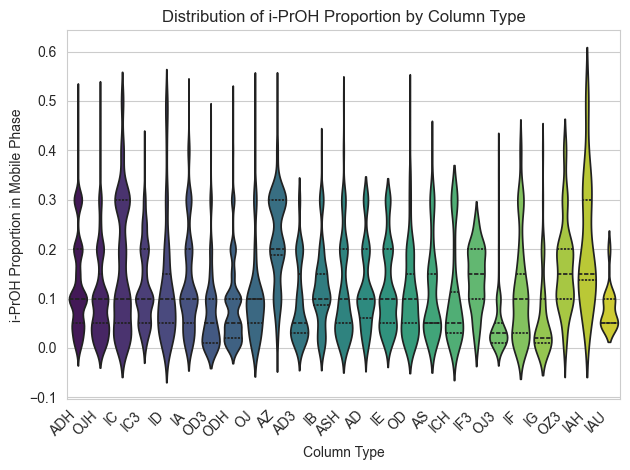


Numerical Summary of i-PrOH Proportion by Column Type:
         count      mean       std    min     25%   50%     75%       max
Column                                                                   
AD       586.0  0.122085  0.084526  0.000  0.0600  0.10  0.2000  0.300000
AD3      564.0  0.089539  0.080023  0.000  0.0300  0.05  0.1500  0.300000
ADH     4884.0  0.129340  0.096777  0.000  0.0500  0.10  0.2000  0.500000
AS       312.0  0.114011  0.094292  0.010  0.0500  0.05  0.1500  0.400000
ASH     1068.0  0.114952  0.100477  0.000  0.0500  0.10  0.2000  0.500000
AZ       344.0  0.222093  0.093199  0.010  0.1875  0.20  0.3000  0.500000
IA      1610.0  0.129065  0.100143  0.000  0.0500  0.10  0.2000  0.500000
IAH       72.0  0.211389  0.128088  0.050  0.1375  0.15  0.3000  0.500000
IAU       54.0  0.079630  0.041797  0.050  0.0500  0.05  0.1000  0.200000
IB       600.0  0.120547  0.080705  0.000  0.0875  0.10  0.1500  0.400000
IC      1862.0  0.166412  0.132650  0.000  0.0500  0.10 

In [11]:
# for each column typ plot i-poh
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plot
sns.set_style("whitegrid")


# Create a violin plot to show the distribution for each column type
# A violin plot is like a box plot but also shows the kernel density estimate of the data.
sns.violinplot(
    x='Column',
    y='i-PrOH_proportion',
    data=paired_df,
    inner='quartile', # Show quartiles inside the violins
    palette='viridis' # Choose a color palette
)



plt.title('Distribution of i-PrOH Proportion by Column Type')
plt.xlabel('Column Type')
plt.ylabel('i-PrOH Proportion in Mobile Phase')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if many columns
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# You can also get a numerical summary:
print("\nNumerical Summary of i-PrOH Proportion by Column Type:")
print(paired_df.groupby('Column')['i-PrOH_proportion'].describe())

C:\Users\gzyla\AppData\Local\Temp\ipykernel_12060\169821948.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


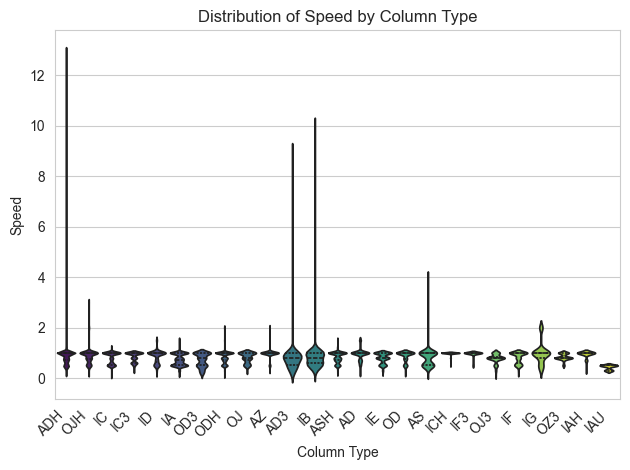


Numerical Summary of Speed by Column Type:
         count      mean       std   min     25%  50%   75%   max
Column                                                           
AD       586.0  0.936519  0.217045  0.20  0.8000  1.0  1.00   1.5
AD3      564.0  0.758688  0.559692  0.15  0.5000  0.8  1.00   9.0
ADH     4884.0  0.835381  0.327539  0.20  0.7000  1.0  1.00  13.0
AS       312.0  0.817949  0.359392  0.20  0.5000  1.0  1.00   4.0
ASH     1068.0  0.834082  0.200116  0.20  0.7000  1.0  1.00   1.5
AZ       344.0  0.966860  0.158365  0.30  1.0000  1.0  1.00   2.0
IA      1610.0  0.728634  0.220578  0.15  0.5000  0.7  1.00   1.5
IAH       72.0  0.947222  0.145324  0.30  1.0000  1.0  1.00   1.0
IAU       54.0  0.433333  0.095166  0.30  0.3000  0.5  0.50   0.5
IB       600.0  0.801500  0.578501  0.20  0.6000  0.8  1.00  10.0
IC      1862.0  0.809291  0.223564  0.10  0.5000  1.0  1.00   1.2
IC3      954.0  0.853082  0.182356  0.30  0.6000  1.0  1.00   1.0
ICH      216.0  0.987037  0.0641

In [12]:
# for each column typ plot i-poh
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plot
sns.set_style("whitegrid")


# Create a violin plot to show the distribution for each column type
# A violin plot is like a box plot but also shows the kernel density estimate of the data.
sns.violinplot(
    x='Column',
    y='Speed',
    data=paired_df,
    inner='quartile', # Show quartiles inside the violins
    palette='viridis' # Choose a color palette
)



plt.title('Distribution of Speed by Column Type')
plt.xlabel('Column Type')
plt.ylabel('Speed')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability if many columns
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# You can also get a numerical summary:
print("\nNumerical Summary of Speed by Column Type:")
print(paired_df.groupby('Column')['Speed'].describe())

Physical Meaning: Scaling RT by flow rate allows you to derive a more fundamental and comparable metric: Retention Volume (VR).
VR=Retention Time×Flow Rate
Retention volume represents the total volume of mobile phase that has passed through the column from the time of injection until the peak maximum of the analyte elutes. This value is generally independent of flow rate (within reasonable limits where column efficiency doesn't drastically change), making it a more robust measure for comparing compound behavior across runs with different flow rates.

In [ ]:
# Chiral Stationary Phase (CSP) Interaction: The primary reason is that the chiral stationary phase (CSP) in the column interacts differently with each enantiomer. One enantiomer might fit more snugly into a binding site on the CSP, form stronger transient bonds (hydrogen bonds, dipole-dipole, pi-pi interactions, inclusion complexes), or experience a more favorable steric fit.
#Three-Point Interaction Model: The "three-point interaction model" is often used to rationalize chiral recognition. It suggests that at least three simultaneous interactions (e.g., hydrogen bonding, π-π stacking, steric repulsion) between the chiral analyte and the CSP are necessary for chiral recognition and separation. The strength and geometry of these interactions will differ for enantiomers.

In [ ]:
# first consider total molecular features, then local features to chiral center, then a feature that destinguishes between enantiomers

In [ ]:
#H-bond Donors (HBD),Count of H-bond Acceptors (HBA):,Topological Polar Surface Area (TPSA),Fraction of sp3 carbons (fsp3) -hydrogen bonding based features

In [ ]:
# pi pi stacking - Count of Aromatic Rings, Aromaticity of Atoms/Bonds,Ring Size,

In [ ]:
# steric repulsion - branching, molecular weight, rotatable bonds

In [ ]:
# calcualte 3d confomers and get 3d features for hbndng, pi-pi and sterics

In [ ]:
# filter for enantiomer pairs and split enantiomer pairs

In [ ]:
# are there trends based on structural data that leads to greater retention time difference controlling for experimental details?

In [ ]:
# https://onlinelibrary.wiley.com/doi/abs/10.1002/(SICI)1520-636X(1997)9:2%3C99::AID-CHIR3%3E3.0.CO;2-B
# https://www.sciencedirect.com/science/article/abs/pii/S002196730000532X
# https://www.sciencedirect.com/science/article/abs/pii/S1570023208005382
